<h2>Problem 1</h2>
We saw how to solve TSPs in this module and in particular presented two approaches to encode a TSP as an integer linear program. In this problem, we will ask you to adapt the TSP solution to the related problem of  𝑘 Travelling Salespeople Problem ( 𝑘-TSP).

Let  𝐺 be a complete graph with  𝑛 vertices that we will label  0,…,𝑛−1 (keeping Python array indexing in mind). Our costs are specified using a matrix  𝐶 wherein  𝐶𝑖,𝑗 is the cost of the edge from vertex  𝑖 to  𝑗 for  𝑖≠𝑗.

In this problem, we have  𝑘≥1 salespeople who must start from vertex  0 of the graph (presumably the location of the sales office) and together visit every location in the graph, each returning back to vertex  0. Each location must be visited exactly once by some salesperson in the team. Therefore, other than vertex  0 (the start/end vertex of every salesperson's tour), no two salesperson tours have a vertex in common. Notice that for  𝑘=1, this is just the regular TSP problem we have studied.

Also, all  𝑘 salespeople must be employed in the tour. In other words, if we have  𝑘=3 then each salesperson must start at  0 and visit a sequence of one or more vertices and come back to  0
 . No salesperson can be "idle".

 <h3>Example-1</h3>
Consider a graph with  5 nodes and the following cost matrix:

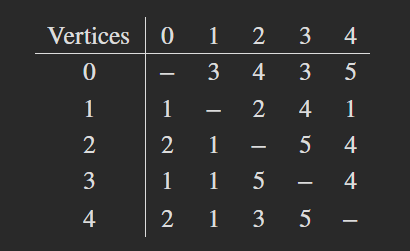

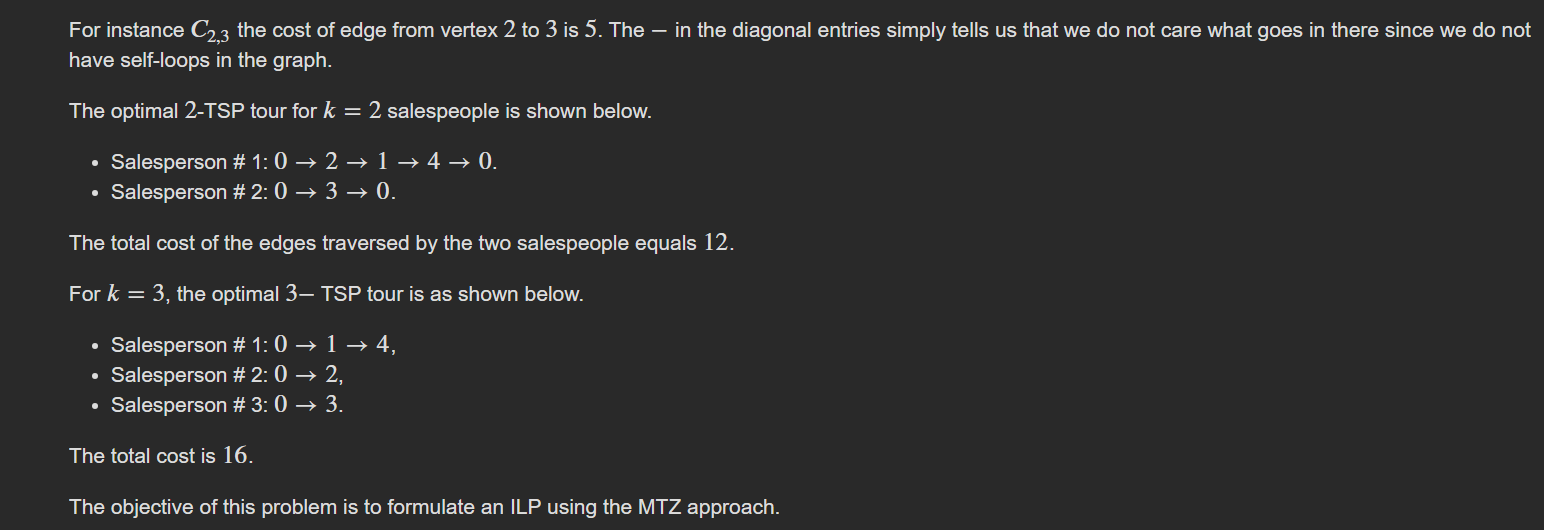



<h2>Problem 1A (MTZ approach)</h2>

We will use the same ILP setup as in our notes (see the notes on Exact Approaches to TSP that includes the ILP encodings we will use in this problem).

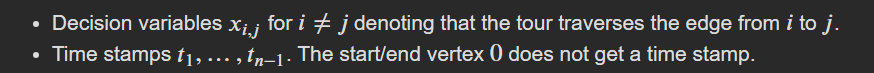

Modify the MTZ approach to incorporate the fact that  𝑘 salespeople are going to traverse the graph.

<h3>(A) Degree Constraints</h3>
What do the new degree constraints look like? Think about how many edges in the tour will need to enter/leave each vertex? Note that you may have to treat vertex  0 differently from the other vertices of the graph.

Your answer below is not graded. However you are encouraged to write it down and check with the answers to select problems provided at the end.

<i> my thought -  Each vertex except vertex0 indegree and outdegree both should be 1. vertex0 will belong to k subtours and hence its indegree and outdegree will be k </i>
This was correct answer 

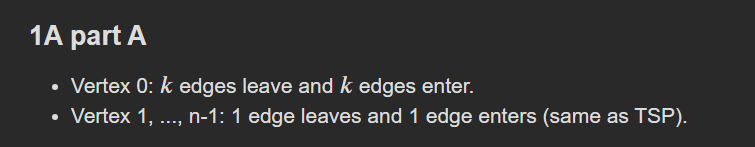

<h3>(B) Time Stamp Constraints</h3>
Formulate the time stamp constraints for the  𝑘-TSP problem. Think about how you would need to change them to eliminate subtour.

Your answer below is not graded. However you are encouraged to write it down and check with the answers to select problems provided at the end.

<i> does not look any change is needed for timestamp based constraint where Xij=1 => tj >= ti +1 since this constraint only ensures that there is no subtour that does not contain vertex0 </i>
This was also correct

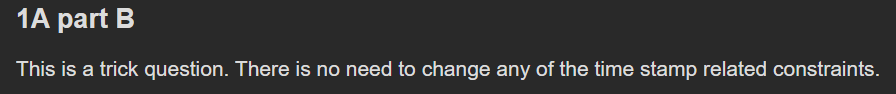

<h3>(C) Implement</h3>

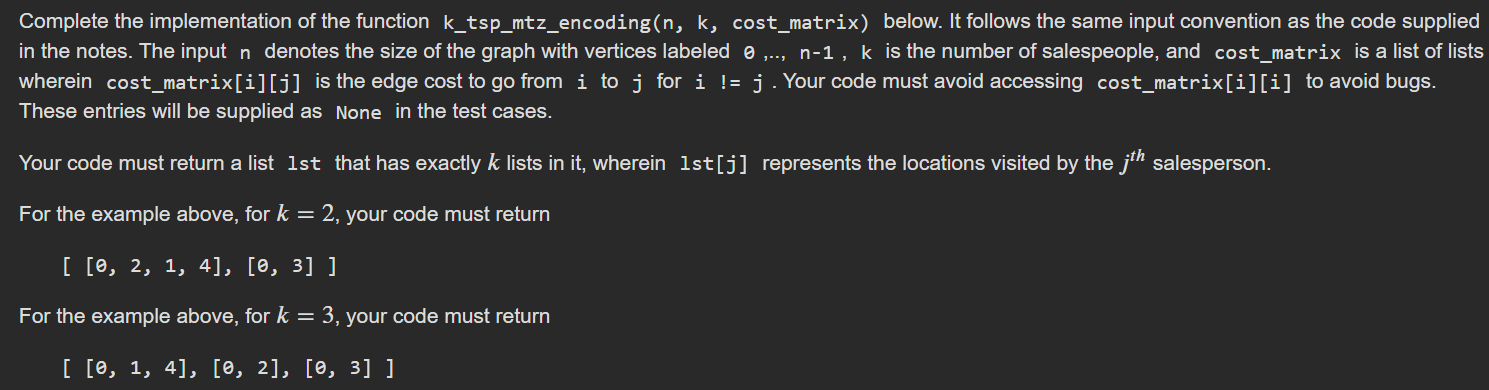


In [14]:
from pulp import *

def k_tsp_mtz_encoding(n, k, cost_matrix):
    # check inputs are OK
    assert 1 <= k < n
    assert len(cost_matrix) == n, f'Cost matrix is not {n}x{n}'
    assert all(len(cj) == n for cj in cost_matrix), f'Cost matrix is not {n}x{n}'
    
    # finish your implementation here
    # create our encoding variables
    binary_vars = [ # add a binary variable x_{ij} if i not = j else simply add None
        [ LpVariable(f'x_{i}_{j}', cat='Binary') if i != j else None for j in range(n)] 
        for i in range(n) ]
        # add time stamps for ranges 1 .. n (skip vertex 0 for timestamps)
    time_stamps = [LpVariable(f't_{j}', lowBound=0, upBound=n, cat='Continuous') for j in range(1, n)]
    # create the problem
    prob = LpProblem('kTSP', LpMinimize)
    # create add the objective function 
    objective_function = lpSum( [ lpSum([xij*cj if xij != None else 0 for (xij, cj) in zip(brow, crow) ])
                           for (brow, crow) in zip(binary_vars, cost_matrix)] )
    
    prob += objective_function 
    # add the degree constraints
    for i in range(n):
        degree = k if i==0 else 1
        # Exactly 'degree' leaving variable
        prob += lpSum([xj for xj in binary_vars[i] if xj != None]) == degree
        # Exactly 'degree' entering
        prob += lpSum([binary_vars[j][i] for j in range(n) if j != i]) == degree

    # add time stamp constraints
    for i in range(1,n):
        for j in range(1, n):
            if i == j: 
                continue
            xij = binary_vars[i][j]
            ti = time_stamps[i-1]
            tj = time_stamps[j -1]
            prob += tj >= ti + xij - (1-xij)*(n+1) # add the constraint
    # Done: solve the problem
    status = prob.solve(PULP_CBC_CMD(msg=False)) # turn off messages
    assert status == constants.LpStatusOptimal, f'Unexpected non-optimal status {status}'

    tour = [[0] for i in range(k)]
    # find all k vertices  that go outward from 0
    sols = [j for (j, xij) in enumerate(binary_vars[0]) if xij != None and xij.varValue >= 0.999]
    
    print(sols)
    for y in range(k):
        tour[y].append(sols[y]) # first vertex going out from 0 in the yth tour
        i = tour[y][-1]
        while i!=0: #tour is not completed
            # find all indices j such that x_ij >= 0.999 
            next = [j for (j, xij) in enumerate(binary_vars[i]) if xij != None and xij.varValue >= 0.999]
            assert len(next) == 1, f'{next}' # there better be just one such vertex or something has gone quite wrong
            i = next[0] # extract the lone solution
            if(i!=0):
                tour[y].append(i)

    # your code must return a list of k-lists [ [0, i1, ..., il], [0, j1,...,jl],...] wherein 
    # the ith entry in our list of lists represents the 
    # tour undertaken by the ith salesperson
    # your code here
    return tour

In [13]:
cost_matrix=[ [None,3,4,3,5],
             [1, None, 2,4, 1],
             [2, 1, None, 5, 4],
             [1, 1, 5, None, 4],
             [2, 1, 3, 5, None] ]
n=5
k=2
all_tours = k_tsp_mtz_encoding(n, k, cost_matrix)
print(f'Your code returned tours: {all_tours}')
assert len(all_tours) == k, f'k={k} must yield two tours -- your code returns {len(all_tours)} tours instead'

tour_cost = 0
for tour in all_tours:
    assert tour[0] == 0, 'Each salesperson tour must start from vertex 0'
    i = 0
    for j in tour[1:]:
        tour_cost += cost_matrix[i][j]
        i = j
    tour_cost += cost_matrix[i][0]

print(f'Tour cost obtained by your code: {tour_cost}')
assert abs(tour_cost - 12) <= 0.001, f'Expected tour cost is 12, your code returned {tour_cost}'
for i in range(1, n):
    is_in_tour = [ 1 if i in tour else 0 for tour in all_tours]
    assert sum(is_in_tour) == 1, f' vertex {i} is in {sum(is_in_tour)} tours -- this is incorrect'

print('test passed: 3 points')


5, 2, [[None, 3, 4, 3, 5], [1, None, 2, 4, 1], [2, 1, None, 5, 4], [1, 1, 5, None, 4], [2, 1, 3, 5, None]]
[2, 3]
Your code returned tours: [[0, 2, 1, 4], [0, 3]]
Tour cost obtained by your code: 12
test passed: 3 points


In [15]:
cost_matrix=[ [None,3,4,3,5],
             [1, None, 2,4, 1],
             [2, 1, None, 5, 4],
             [1, 1, 5, None, 4],
             [2, 1, 3, 5, None] ]
n=5
k=3
all_tours = k_tsp_mtz_encoding(n, k, cost_matrix)
print(f'Your code returned tours: {all_tours}')
assert len(all_tours) == k, f'k={k} must yield two tours -- your code returns {len(all_tours)} tours instead'

tour_cost = 0
for tour in all_tours:
    assert tour[0] == 0, 'Each salesperson tour must start from vertex 0'
    i = 0
    for j in tour[1:]:
        tour_cost += cost_matrix[i][j]
        i = j
    tour_cost += cost_matrix[i][0]

print(f'Tour cost obtained by your code: {tour_cost}')
assert abs(tour_cost - 16) <= 0.001, f'Expected tour cost is 16, your code returned {tour_cost}'
for i in range(1, n):
    is_in_tour = [ 1 if i in tour else 0 for tour in all_tours]
    assert sum(is_in_tour) == 1, f' vertex {i} is in {sum(is_in_tour)} tours -- this is incorrect'

print('test passed: 2 points')

[1, 2, 3]
Your code returned tours: [[0, 1, 4], [0, 2], [0, 3]]
Tour cost obtained by your code: 16
test passed: 2 points


In [16]:
cost_matrix = [ 
 [None, 1, 1, 1, 1, 1, 1, 1],
    [0, None, 1, 2, 1, 1, 1, 1],
    [1, 0, None, 1, 2, 2, 2, 1],
    [1, 2, 2, None, 0, 1, 2, 1],
    [1, 1, 1, 1, None, 1, 1, 1],
    [0,  1, 2, 1, 1, None, 1, 1],
    [1, 0,  1, 2, 2, 2,None, 1],
    [1, 2, 2, 0, 1, 2, 1, None],
]
n = 8
k = 2

all_tours = k_tsp_mtz_encoding(n, k, cost_matrix)
print(f'Your code returned tours: {all_tours}')
assert len(all_tours) == k, f'k={k} must yield two tours -- your code returns {len(all_tours)} tours instead'

tour_cost = 0
for tour in all_tours:
    assert tour[0] == 0, 'Each salesperson tour must start from vertex 0'
    i = 0
    for j in tour[1:]:
        tour_cost += cost_matrix[i][j]
        i = j
    tour_cost += cost_matrix[i][0]

print(f'Tour cost obtained by your code: {tour_cost}')
assert abs(tour_cost - 4) <= 0.001, f'Expected tour cost is 4, your code returned {tour_cost}'
for i in range(1, n):
    is_in_tour = [ 1 if i in tour else 0 for tour in all_tours]
    assert sum(is_in_tour) == 1, f' vertex {i} is in {sum(is_in_tour)} tours -- this is incorrect'

print('test passed: 3 points')

[6, 7]
Your code returned tours: [[0, 6, 2, 1], [0, 7, 3, 4, 5]]
Tour cost obtained by your code: 4
test passed: 3 points


In [17]:
cost_matrix = [ 
 [None, 1, 1, 1, 1, 1, 1, 1],
    [0, None, 1, 2, 1, 1, 1, 1],
    [1, 0, None, 1, 2, 2, 2, 1],
    [1, 2, 2, None, 0, 1, 2, 1],
    [1, 1, 1, 1, None, 1, 1, 1],
    [0,  1, 2, 1, 1, None, 1, 1],
    [1, 0,  1, 2, 2, 2,None, 1],
    [1, 2, 2, 0, 1, 2, 1, None],
]
n = 8
k = 4

all_tours = k_tsp_mtz_encoding(n, k, cost_matrix)
print(f'Your code returned tours: {all_tours}')
assert len(all_tours) == k, f'k={k} must yield two tours -- your code returns {len(all_tours)} tours instead'

tour_cost = 0
for tour in all_tours:
    assert tour[0] == 0, 'Each salesperson tour must start from vertex 0'
    i = 0
    for j in tour[1:]:
        tour_cost += cost_matrix[i][j]
        i = j
    tour_cost += cost_matrix[i][0]

print(f'Tour cost obtained by your code: {tour_cost}')
assert abs(tour_cost - 6) <= 0.001, f'Expected tour cost is 6, your code returned {tour_cost}'
for i in range(1, n):
    is_in_tour = [ 1 if i in tour else 0 for tour in all_tours]
    assert sum(is_in_tour) == 1, f' vertex {i} is in {sum(is_in_tour)} tours -- this is incorrect'

print('test passed: 2 points')

[2, 5, 6, 7]
Your code returned tours: [[0, 2], [0, 5], [0, 6, 1], [0, 7, 3, 4]]
Tour cost obtained by your code: 6
test passed: 2 points


In [18]:
from random import uniform, randint

def create_cost(n):
    return [ [uniform(0, 5) if i != j else None for j in range(n)] for i in range(n)]

for trial in range(5):
    print(f'Trial # {trial}')
    n = randint(5, 11)
    k = randint(2, n//2)
    print(f' n= {n}, k={k}')
    cost_matrix = create_cost(n)
    print('cost_matrix = ')
    print(cost_matrix)
    all_tours = k_tsp_mtz_encoding(n, k, cost_matrix)
    print(f'Your code returned tours: {all_tours}')
    assert len(all_tours) == k, f'k={k} must yield two tours -- your code returns {len(all_tours)} tours instead'

    tour_cost = 0
    for tour in all_tours:
        assert tour[0] == 0, 'Each salesperson tour must start from vertex 0'
        i = 0
        for j in tour[1:]:
            tour_cost += cost_matrix[i][j]
            i = j
        tour_cost += cost_matrix[i][0]

    print(f'Tour cost obtained by your code: {tour_cost}')
    #assert abs(tour_cost - 6) <= 0.001, f'Expected tour cost is 6, your code returned {tour_cost}'
    for i in range(1, n):
        is_in_tour = [ 1 if i in tour else 0 for tour in all_tours]
        assert sum(is_in_tour) == 1, f' vertex {i} is in {sum(is_in_tour)} tours -- this is incorrect'
    print('------')
print('test passed: 15 points')

Trial # 0
 n= 10, k=4
cost_matrix = 
[[None, 3.205708584025622, 2.7268523516374006, 1.4962993056221756, 3.475229340269559, 1.9121407853603, 2.9432893107713087, 4.613356112308286, 1.8383828560469633, 0.44488807188299007], [4.964299490601619, None, 3.6740388288482624, 1.537849311920897, 0.6063696523505924, 1.1909210834246369, 1.873322947753836, 4.51155316248957, 4.00228440894891, 1.2555474834372116], [3.9148811746003687, 3.058721728445752, None, 1.8420498496016275, 0.2820697666431482, 0.28501808594185774, 4.455548327812583, 3.7600749602061057, 1.246330154326628, 0.4175281203780007], [4.098128086147134, 4.144325810178536, 2.496574571091399, None, 1.3902211483859435, 0.43344119284410176, 1.2126553234046549, 2.7488227269422167, 0.5261463664741983, 0.05055360717702573], [3.7520802588821405, 1.3350036996276442, 1.6102037206756925, 4.174818242150043, None, 0.08285437244577143, 4.247276049208704, 1.0434306753742684, 0.8618820652221298, 3.8390418049692676], [3.6995037114863134, 2.422167889054599

<h2>Problem 1 B</h2>
Notice that in previous part, it happens that with  𝑘=4 salespeople, we actually get a worse cost than using  𝑘=3 people. You can try out a few examples to convince yourself as to why this happens.

We wish to modify the problem to allow salespeople to idle. In other words, although we input  𝑘 salespeople, the tour we construct may involve  1≤𝑙≤𝑘
  salespeople.

Modify the ILP formulation from the previous problem to solve the problem of up to  𝑘 people rather than exactly  𝑘 salespeople. Note that we still require that every vertex be visited exactly once by some salesperson.

Complete the implementation of the function upto_k_tsp_mtz_encoding(n, k, cost_matrix) below. It follows the same input convention as previous problem but note that we are now computing a tour with at most  𝑘
  salespeople. In other words, not all salespeople need be employed in the tour.

Your code must return a list lst that has less than or equal to  𝑘
  lists, wherein lst[j] represents the locations visited by the  𝑗𝑡ℎ
  salesperson.

For Example-1 from the previous part above, for  𝑘=2
  or  𝑘=3, your code must return

[ [0, 3, 1, 4, 2] ]

As it turns out, in this example a single salesperson suffices to yield optimal cost.

In [23]:
from pulp import *
def upto_k_tsp_mtz_encoding(n, k, cost_matrix):
    
    # finish your implementation here
    # your code must return a list of k-lists [ [0, i1, ..., il], [0, j1,...,jl],...] wherein 
    # the ith entry in our list of lists represents the 
    # tour undertaken by the ith salesperson
    # your code here
        # check inputs are OK
    assert 1 <= k < n
    assert len(cost_matrix) == n, f'Cost matrix is not {n}x{n}'
    assert all(len(cj) == n for cj in cost_matrix), f'Cost matrix is not {n}x{n}'
    
    # finish your implementation here
    # create our encoding variables
    binary_vars = [ # add a binary variable x_{ij} if i not = j else simply add None
        [ LpVariable(f'x_{i}_{j}', cat='Binary') if i != j else None for j in range(n)] 
        for i in range(n) ]
        # add time stamps for ranges 1 .. n (skip vertex 0 for timestamps)
    time_stamps = [LpVariable(f't_{j}', lowBound=0, upBound=n, cat='Continuous') for j in range(1, n)]
    # create the problem
    prob = LpProblem('kTSP', LpMinimize)
    # create add the objective function 
    objective_function = lpSum( [ lpSum([xij*cj if xij != None else 0 for (xij, cj) in zip(brow, crow) ])
                           for (brow, crow) in zip(binary_vars, cost_matrix)] )
    
    prob += objective_function 
    # add the degree constraints
    for i in range(n):
        if i==0:
            prob += lpSum([xj for xj in binary_vars[i] if xj != None]) <= k
            prob += lpSum([binary_vars[j][i] for j in range(n) if j != i]) <=k
            #should we make constraing in-degree == out-degree ?
        else:
            # Exactly 'out-degree' leaving variable
            prob += lpSum([xj for xj in binary_vars[i] if xj != None]) == 1
            # Exactly 'in-degree' entering
            prob += lpSum([binary_vars[j][i] for j in range(n) if j != i]) == 1

    # add time stamp constraints
    for i in range(1,n):
        for j in range(1, n):
            if i == j: 
                continue
            xij = binary_vars[i][j]
            ti = time_stamps[i-1]
            tj = time_stamps[j -1]
            prob += tj >= ti + xij - (1-xij)*(n+1) # add the constraint
    # Done: solve the problem
    status = prob.solve(PULP_CBC_CMD(msg=False)) # turn off messages
    assert status == constants.LpStatusOptimal, f'Unexpected non-optimal status {status}'

    
    # find all k vertices  that go outward from 0
    sols = [j for (j, xij) in enumerate(binary_vars[0]) if xij != None and xij.varValue >= 0.999]
    
    tour = [[0] for i in range(len(sols))]

    print(f'{sols},{tour}')
    for y in range(len(sols)):
        tour[y].append(sols[y]) # first vertex going out from 0 in the yth tour
        i = tour[y][-1]
        while i!=0: #tour is not completed
            # find all indices j such that x_ij >= 0.999 
            next = [j for (j, xij) in enumerate(binary_vars[i]) if xij != None and xij.varValue >= 0.999]
            assert len(next) == 1, f'{next}' # there better be just one such vertex or something has gone quite wrong
            i = next[0] # extract the lone solution
            if(i!=0):
                tour[y].append(i)

    # your code must return a list of k-lists [ [0, i1, ..., il], [0, j1,...,jl],...] wherein 
    # the ith entry in our list of lists represents the 
    # tour undertaken by the ith salesperson
    # your code here
    return tour

In [24]:
cost_matrix=[ [None,3,4,3,5],
             [1, None, 2,4, 1],
             [2, 1, None, 5, 4],
             [1, 1, 5, None, 4],
             [2, 1, 3, 5, None] ]
n=5
k=3
all_tours = upto_k_tsp_mtz_encoding(n, k, cost_matrix)
print(f'Your code returned tours: {all_tours}')
assert len(all_tours) <= k, f'<= {k} tours -- your code returns {len(all_tours)} tours instead'

tour_cost = 0
for tour in all_tours:
    assert tour[0] == 0, 'Each salesperson tour must start from vertex 0'
    i = 0
    for j in tour[1:]:
        tour_cost += cost_matrix[i][j]
        i = j
    tour_cost += cost_matrix[i][0]

assert len(all_tours) == 1, f'In this example, just one salesperson is needed to optimally visit all vertices. Your code returns {len(all_tours)}'
print(f'Tour cost obtained by your code: {tour_cost}')
assert abs(tour_cost - 10) <= 0.001, f'Expected tour cost is 10, your code returned {tour_cost}'
for i in range(1, n):
    is_in_tour = [ 1 if i in tour else 0 for tour in all_tours]
    assert sum(is_in_tour) == 1, f' vertex {i} is in {sum(is_in_tour)} tours -- this is incorrect'

print('test passed: 3 points')

[3],[[0]]
Your code returned tours: [[0, 3, 1, 4, 2]]
Tour cost obtained by your code: 10
test passed: 3 points


In [25]:
cost_matrix = [ 
 [None, 1, 1, 1, 1, 1, 1, 1],
    [0, None, 1, 2, 1, 1, 1, 1],
    [1, 0, None, 1, 2, 2, 2, 1],
    [1, 2, 2, None, 0, 1, 2, 1],
    [1, 1, 1, 1, None, 1, 1, 1],
    [0,  1, 2, 1, 1, None, 1, 1],
    [1, 0,  1, 2, 2, 2,None, 1],
    [1, 2, 2, 0, 1, 2, 1, None],
]
n = 8
k = 5

all_tours = upto_k_tsp_mtz_encoding(n, k, cost_matrix)
print(f'Your code returned tours: {all_tours}')
assert len(all_tours) <= k, f'k={k} must yield two tours -- your code returns {len(all_tours)} tours instead'

tour_cost = 0
for tour in all_tours:
    assert tour[0] == 0, 'Each salesperson tour must start from vertex 0'
    i = 0
    for j in tour[1:]:
        tour_cost += cost_matrix[i][j]
        i = j
    tour_cost += cost_matrix[i][0]

print(f'Tour cost obtained by your code: {tour_cost}')
assert abs(tour_cost - 4) <= 0.001, f'Expected tour cost is 4, your code returned {tour_cost}'
for i in range(1, n):
    is_in_tour = [ 1 if i in tour else 0 for tour in all_tours]
    assert sum(is_in_tour) == 1, f' vertex {i} is in {sum(is_in_tour)} tours -- this is incorrect'

print('test passed: 3 points')

[6, 7],[[0], [0]]
Your code returned tours: [[0, 6, 2, 1], [0, 7, 3, 4, 5]]
Tour cost obtained by your code: 4
test passed: 3 points


In [26]:
from random import uniform, randint

def create_cost(n):
    return [ [uniform(0, 5) if i != j else None for j in range(n)] for i in range(n)]

for trial in range(20):
    print(f'Trial # {trial}')
    n = randint(5, 11)
    k = randint(2, n//2)
    print(f' n= {n}, k={k}')
    cost_matrix = create_cost(n)
    print('cost_matrix = ')
    print(cost_matrix)
    all_tours = upto_k_tsp_mtz_encoding(n, k, cost_matrix)
    print(f'Your code returned tours: {all_tours}')
    assert len(all_tours) <= k, f'k={k} must yield two tours -- your code returns {len(all_tours)} tours instead'

    tour_cost = 0
    for tour in all_tours:
        assert tour[0] == 0, 'Each salesperson tour must start from vertex 0'
        i = 0
        for j in tour[1:]:
            tour_cost += cost_matrix[i][j]
            i = j
        tour_cost += cost_matrix[i][0]

    print(f'Tour cost obtained by your code: {tour_cost}')
    #assert abs(tour_cost - 6) <= 0.001, f'Expected tour cost is 6, your code returned {tour_cost}'
    for i in range(1, n):
        is_in_tour = [ 1 if i in tour else 0 for tour in all_tours]
        assert sum(is_in_tour) == 1, f' vertex {i} is in {sum(is_in_tour)} tours -- this is incorrect'
    print('------')
print('test passed: 4 points')

Trial # 0
 n= 8, k=2
cost_matrix = 
[[None, 3.0966527490615556, 3.9466406218337617, 3.3602372109633967, 3.382882006016003, 4.880601123847628, 1.7092382353958213, 4.8052708294738755], [0.09168708368776146, None, 3.2284477623364722, 1.1966291008040364, 3.514407329712256, 3.6615708393356075, 2.738543574262375, 3.2021556222444145], [1.2951460825539978, 0.8145770605454805, None, 0.24035503442564166, 2.8849906979168938, 3.6530545942944985, 2.009995166656839, 3.7695622989173327], [3.0262273903050247, 2.0988850047723244, 2.2294348047334966, None, 3.093829533566403, 3.7336962038046444, 3.406988046367249, 1.1021067762057606], [2.946676947339242, 2.4112288258808396, 1.8416837588866826, 4.1909481323583915, None, 3.303177512332447, 1.8277057166071802, 1.2321204778038601], [2.496818199719573, 0.7976243779534564, 1.6674465566205332, 0.3858792063526256, 3.20801895460196, None, 0.9247722233608069, 0.118813821720683], [3.890781899639551, 1.710034710967825, 1.3912727254697925, 2.922754325338456, 0.882918

<h3>Problem 2 (10 points)</h3>

We noted the use of Christofides algorithm for metric TSP. We noted that for non-metric TSPs it does not work. In fact, the shortcutting used in Christofides algorithm can be arbitrarily bad for a TSP that is symmetric but fails to be a metric TSP.

In this example, we would like you to frame a symmetric TSP instance ( 𝐶𝑖𝑗=𝐶𝑗𝑖
 ) with  5 vertices wherein the algorithm obtained by "shortcutting" the minimum spanning tree (MST), that would be a 2-factor approximation for metric TSP, yields an answer that can be quite "far off" from the optimal solution.

Enter a symmetric cost-matrix for the TSP below as a 5x5 matrix as a list of lists following convention in our notes. such that the optimal answer is at least  106
  times smaller than that obtained by the TSP-based approximation. We will test your answer by running the TSP with shortcutting algorithm.

Hint: Force the edges  (0,1),(1,2),(2,3) and  (3,4)  to be the minimum spanning tree. But make the weight of the edge form  4 back to  0  very high.

Note: this problem is tricky and requires you to be very familiar with how Christofides algorithm works. It may be wise to attempt the remaining problems first before this one. Do not worry about the diagonal entry of your matrices.

In [44]:
# Write down the cost matrix as a list of lists. Remember, we want an example with $5$ vertices
# cost_matrix = [[..], [...],[...]]
# The cost matrix should represent a TSP instance such that the optimal answer is 10^6 smaller than the 
# answer obtained by shortcutting a minimum spanning tree.
# your code here

cost_matrix=[ [None,1,10,10,100000000],
             [1, None, 1,10, 10],
             [10, 1, None, 1, 10],
             [10, 10, 1, None, 1],
             [100000000, 10, 10, 1, None] ]


In [45]:
# check that the cost matrix is symmetric.
assert len(cost_matrix) == 5, f'Cost matrix must have 5 rows. Yours has {len(cost_matrix)} rows'
assert all(len(cj) == 5 for cj in cost_matrix), f'Each row of the cost matrix must have 5 entries.'
for i in range(5):
    for j in range(i):
        assert cost_matrix[i][j] == cost_matrix[j][i], f'Cost matrix fails to be symmetric at entries {(i,j)} and {(j,i)}'
print('Structure of your cost matrix looks OK (3 points).')

Structure of your cost matrix looks OK (3 points).


In [46]:

# MST based tsp approximation
import networkx as nx

# This code implements the simple MST based shortcutting approach that would yield factor of 2
# approximation for metric TSPs.
def minimum_spanning_tree_tsp(n, cost_matrix):
    G = nx.Graph()
    for i in range(n):
        for j in range(i):
            G.add_edge(i, j, weight=cost_matrix[i][j])
    T = nx.minimum_spanning_tree(G)
    print(f'MST for your graph has the edges {T.edges}')
    mst_cost = 0
    mst_dict = {} # store mst as a dictionary
    for (i,j) in T.edges:
        mst_cost += cost_matrix[i][j]
        if i in mst_dict:
            mst_dict[i].append(j)
        else:
            mst_dict[i] = [j]
        if j in mst_dict:
            mst_dict[j].append(i)
        else:
            mst_dict[j] = [i]
    print(f'MST cost: {mst_cost}')
    print(mst_dict)
    # Let's form a tour with short cutting
    def traverse_mst(tour_so_far, cur_node):
        assert cur_node in mst_dict
        next_nodes = mst_dict[cur_node]
        for j in next_nodes:
            if j in tour_so_far:
                continue
            tour_so_far.append(j)
            traverse_mst(tour_so_far, j)
        return
    tour = [0]
    traverse_mst(tour, 0)
    i = 0
    tour_cost = 0
    for j in tour[1:]:
        tour_cost += cost_matrix[i][j]
        i = j
    tour_cost += cost_matrix[i][0]
    return tour, tour_cost

In [47]:
# optimal TSP tour taken from our notes using MTZ encoding
from pulp import *

def mtz_encoding_tsp(n, cost_matrix):
    assert len(cost_matrix) == n, f'Cost matrix is not {n}x{n}'
    assert all(len(cj) == n for cj in cost_matrix), f'Cost matrix is not {n}x{n}'
    # create our encoding variables
    binary_vars = [ # add a binary variable x_{ij} if i not = j else simply add None
        [ LpVariable(f'x_{i}_{j}', cat='Binary') if i != j else None for j in range(n)] 
        for i in range(n) ]
    # add time stamps for ranges 1 .. n (skip vertex 0 for timestamps)
    time_stamps = [LpVariable(f't_{j}', lowBound=0, upBound=n, cat='Continuous') for j in range(1, n)]
    # create the problem
    prob = LpProblem('TSP-MTZ', LpMinimize)
    # create add the objective function 
    objective_function = lpSum( [ lpSum([xij*cj if xij != None else 0 for (xij, cj) in zip(brow, crow) ])
                           for (brow, crow) in zip(binary_vars, cost_matrix)] )
    
    prob += objective_function 
    
    # add the degree constraints
    for i in range(n):
        # Exactly one leaving variable
        prob += lpSum([xj for xj in binary_vars[i] if xj != None]) == 1
        # Exactly one entering
        prob += lpSum([binary_vars[j][i] for j in range(n) if j != i]) == 1
    # add time stamp constraints
    for i in range(1,n):
        for j in range(1, n):
            if i == j: 
                continue
            xij = binary_vars[i][j]
            ti = time_stamps[i-1]
            tj = time_stamps[j -1]
            prob += tj >= ti + xij - (1-xij)*(n+1) # add the constraint
    # Done: solve the problem
    status = prob.solve(PULP_CBC_CMD(msg=False)) # turn off messages
    assert status == constants.LpStatusOptimal, f'Unexpected non-optimal status {status}'
    # Extract the tour
    tour = [0]
    tour_cost = 0
    while len(tour) < n:
        i = tour[-1]
        # find all indices j such that x_ij >= 0.999 
        sols = [j for (j, xij) in enumerate(binary_vars[i]) if xij != None and xij.varValue >= 0.999]
        assert len(sols) == 1, f'{sols}' # there better be just one such vertex or something has gone quite wrong
        j = sols[0] # extract the lone solutio 
        tour_cost = tour_cost + cost_matrix[i][j] # add to the tour cost
        tour.append(j) # append to the tour
        assert j != 0
    i = tour[-1]
    tour_cost = tour_cost + cost_matrix[i][0]
    return tour, tour_cost
        

In [48]:
#test that exact answer is 10^6 times smaller than approximate answer.
# compute MST based approximation
tour, tour_cost = minimum_spanning_tree_tsp(5, cost_matrix)
print(f'MST approximation yields tour is {tour} with cost {tour_cost}')
# compute exact answer
opt_tour, opt_tour_cost = mtz_encoding_tsp(5, cost_matrix)
print(f'Optimal tour is {opt_tour} with cost {opt_tour_cost}')
# check that the fraction is 1million times apart.
print(f'result = {tour_cost},{opt_tour_cost},{tour_cost/opt_tour_cost}')
assert tour_cost/opt_tour_cost >= 1E+06, 'The TSP + shortcutting tour must be at least 10^6 times costlier than optimum. In your case, the ratio is {tour_cost/opt_tour_cost}'
print('Test passed: 7 points')

MST for your graph has the edges [(1, 0), (1, 2), (2, 3), (3, 4)]
MST cost: 4
{1: [0, 2], 0: [1], 2: [1, 3], 3: [2, 4], 4: [3]}
MST approximation yields tour is [0, 1, 2, 3, 4] with cost 100000004
Optimal tour is [0, 2, 3, 4, 1] with cost 23
result = 100000004,23,4347826.260869565
Test passed: 7 points


<h2>Problem 3 - TSP with additional constraints</h2>

In this problem, we wish to solve TSP with additional constraints. Suppose we are given a TSP instance in the form of a  𝑛×𝑛  matrix  𝐶  representing a complete graph.

We wish to solve a TSP but with additional constraints specified as a list  [(𝑖0,𝑗0),…,(𝑖𝑘,𝑗𝑘)]  wherein each pair  (𝑖𝑙,𝑗𝑙)  in the list specifies that vertex  𝑖𝑙 
  must be visited in the tour before vertex  𝑗𝑙 . Assume that the tour starts/ends at vertex  0  and none of the vertices in the constraint list is  0. I.e,  𝑖𝑙≠0,𝑗𝑙≠0
  for all  0≤𝑙≤𝑘.

  Modify one of the ILP encodings we have presented to solve TSP with extra constraints. Implement your solution in the function tsp_with_extra_constraints(n, cost_matrix, constr_list) where the extra argument constr_list is a list of pairs [(i0,j0),...., (ik, jk)] that specify for each pair (il,jl) that vertex il must be visited before jl. Assume that the problem is feasible (no need to handle infeasible instances). Your code should output the optimal tour as a list.

  

In [ ]:
def tsp_with_extra_constraints(n, cost_matrix, constraints):
    assert len(cost_matrix) == n, f'Cost matrix is not {n}x{n}'
    assert all(len(cj) == n for cj in cost_matrix), f'Cost matrix is not {n}x{n}'
    assert all( 1 <= i < n and 1 <= j < n and i != j for (i,j) in constraints)
    # TODO: encode the problem in pulp (a) decision variables; (b) constraints; (c) objective; (d) solve and extract
    #       solution. This is going to be very close to the MTZ encoding that we have presented in our notes. You can use
    #       our code as a starting point.
    # your code here
    # create our encoding variables
    binary_vars = [ # add a binary variable x_{ij} if i not = j else simply add None
        [ LpVariable(f'x_{i}_{j}', cat='Binary') if i != j else None for j in range(n)] 
        for i in range(n) ]
    # add time stamps for ranges 1 .. n (skip vertex 0 for timestamps)
    time_stamps = [LpVariable(f't_{j}', lowBound=0, upBound=n, cat='Continuous') for j in range(1, n)]
    # create the problem
    prob = LpProblem('TSP-MTZ', LpMinimize)
    # create add the objective function 
    objective_function = lpSum( [ lpSum([xij*cj if xij != None else 0 for (xij, cj) in zip(brow, crow) ])
                           for (brow, crow) in zip(binary_vars, cost_matrix)] )
    
    prob += objective_function 
    
    # add the degree constraints
    for i in range(n):
        # Exactly one leaving variable
        prob += lpSum([xj for xj in binary_vars[i] if xj != None]) == 1
        # Exactly one entering
        prob += lpSum([binary_vars[j][i] for j in range(n) if j != i]) == 1
    # add time stamp constraints
    for i in range(1,n):
        for j in range(1, n):
            if i == j: 
                continue
            xij = binary_vars[i][j]
            
            ti = time_stamps[i-1]
            tj = time_stamps[j -1]
            if (j,i) in constraints: # this is opposite constraint of additional constraint. so make it not possible
                # print(f'ignoring constraint ({i},{j})')
                # adding constraint the is not possible to satisfy/ if i->j is selected ti >= tj
                # prob += tj >= ti + xij*(n+10) - (1-xij)*(n+1) # add the not happening constraint
                prob += xij >= 0
                prob += xij <= 0 # removing edge xij from tour
                print(f'')
            else:
                if (i,j) in constraints:
                    prob += tj >= ti + xij # add the constraint irrespective of xij=1 or not
                else:
                    prob += tj >= ti + xij - (1-xij)*(n+1) # add the constraint
    # Done: solve the problem
    status = prob.solve(PULP_CBC_CMD(msg=False)) # turn off messages
    assert status == constants.LpStatusOptimal, f'Unexpected non-optimal status {status}'
    # Extract the tour
    tour = [0]
    tour_cost = 0
    while len(tour) < n:
        i = tour[-1]
        # find all indices j such that x_ij >= 0.999 
        sols = [j for (j, xij) in enumerate(binary_vars[i]) if xij != None and xij.varValue >= 0.999]
        assert len(sols) == 1, f'{sols}' # there better be just one such vertex or something has gone quite wrong
        j = sols[0] # extract the lone solutio 
        tour_cost = tour_cost + cost_matrix[i][j] # add to the tour cost
        tour.append(j) # append to the tour
        assert j != 0
    i = tour[-1]
    tour_cost = tour_cost + cost_matrix[i][0]
    print(f'tour_cost={tour_cost}')
    return tour
       

In [93]:
cost_matrix=[ [None,3,4,3,5],
             [1, None, 2,4, 1],
             [2, 1, None, 5, 4],
             [1, 1, 5, None, 4],
             [2, 1, 3, 5, None] ]
n=5
constraints = [(3,4),(1,2)]
tour = tsp_with_extra_constraints(n, cost_matrix, constraints)
i = 0
tour_cost = 0
for j in tour[1:]:
    tour_cost += cost_matrix[i][j]
    i = j
tour_cost += cost_matrix[i][0]
print(f'Tour:{tour}')
print(f'Cost of your tour: {tour_cost}')
assert abs(tour_cost-10) <= 0.001, 'Expected cost was 10'
for i in range(n):
    num = sum([1 if j == i else 0 for j in tour])
    assert  num == 1, f'Vertex {i} repeats {num} times in tour'
for (i, j) in constraints:
    assert tour.index(i) < tour.index(j), f'Tour does not respect constraint {(i,j)}'
print('Test Passed (3 points)')

adding constraint x_1_2
removing constraint x_2_1
adding constraint x_3_4
removing constraint x_4_3
tour_cost=10
Tour:[0, 3, 1, 4, 2]
Cost of your tour: 10
Test Passed (3 points)


In [94]:
cost_matrix=[ [None,3,4,3,5],
             [1, None, 2,4, 1],
             [2, 1, None, 5, 4],
             [1, 1, 5, None, 4],
             [2, 1, 3, 5, None] ]
n=5
constraints = [(4,3),(1,2)]
tour = tsp_with_extra_constraints(n, cost_matrix, constraints)
i = 0
tour_cost = 0
for j in tour[1:]:
    tour_cost += cost_matrix[i][j]
    i = j
tour_cost += cost_matrix[i][0]
print(f'Tour:{tour}')
print(f'Cost of your tour: {tour_cost}')
for (i, j) in constraints:
    assert tour.index(i) < tour.index(j), f'Tour does not respect constraint {(i,j)}'
assert abs(tour_cost-13) <= 0.001, 'Expected cost was 13'
for i in range(n):
    num = sum([1 if j == i else 0 for j in tour])
    assert  num == 1, f'Vertex {i} repeats {num} times in tour'

print('Test Passed (3 points)')

adding constraint x_1_2
removing constraint x_2_1
removing constraint x_3_4
adding constraint x_4_3
tour_cost=13
Tour:[0, 1, 4, 2, 3]
Cost of your tour: 13
Test Passed (3 points)


In [95]:
from random import uniform, randint

def create_cost(n):
    return [ [uniform(0, 5) if i != j else None for j in range(n)] for i in range(n)]

for trial in range(20):
    print(f'Trial # {trial}')
    n = randint(6, 11)
    cost_matrix = create_cost(n)
    constraints = [(1, 3), (4, 2), (n-1, 1), (n-2, 2)]
    tour = tsp_with_extra_constraints(n, cost_matrix, constraints)
    i = 0
    tour_cost = 0
    for j in tour[1:]:
        tour_cost += cost_matrix[i][j]
        i = j
    tour_cost += cost_matrix[i][0]
    print(f'Tour:{tour}')
    print(f'Cost of your tour: {tour_cost}')
    for i in range(n):
        num = sum([1 if j == i else 0 for j in tour])
        assert  num == 1, f'Vertex {i} repeats {num} times in tour'
    for (i, j) in constraints:
        assert tour.index(i) < tour.index(j), f'Tour does not respect constraint {(i,j)}'
print('Test Passed (10 points)')

Trial # 0
adding constraint x_1_3
removing constraint x_1_10
removing constraint x_2_4
removing constraint x_2_9
removing constraint x_3_1
adding constraint x_4_2
adding constraint x_9_2
adding constraint x_10_1
tour_cost=7.778693038221921
Tour:[0, 4, 10, 9, 5, 1, 3, 7, 8, 6, 2]
Cost of your tour: 7.778693038221921
Trial # 1
adding constraint x_1_3
removing constraint x_1_7
removing constraint x_2_4
removing constraint x_2_6
removing constraint x_3_1
adding constraint x_4_2
adding constraint x_6_2
adding constraint x_7_1
tour_cost=9.473872368019492
Tour:[0, 6, 7, 1, 5, 3, 4, 2]
Cost of your tour: 9.473872368019492
Trial # 2
adding constraint x_1_3
removing constraint x_1_10
removing constraint x_2_4
removing constraint x_2_9
removing constraint x_3_1
adding constraint x_4_2
adding constraint x_9_2
adding constraint x_10_1
tour_cost=11.680542627641662
Tour:[0, 9, 10, 4, 6, 1, 7, 3, 5, 8, 2]
Cost of your tour: 11.680542627641662
Trial # 3
adding constraint x_1_3
removing constraint x_1_5